#### **Installing And Importing The Necessary Modules**

In [2]:
# Installing The Necessary Modules
!pip install sentence-transformers -qqq

# Importing The Necessary Modules And Packages
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from kagglehub import KaggleDatasetAdapter, dataset_load
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#### **Text Embedding Initialization Using Sentence Transformers**

This step initializes a pre-trained sentence embedding model using the Sentence Transformers library. The model **all-MiniLM-L6-v2** is a lightweight yet powerful transformer designed to convert text into dense vector representations, enabling downstream tasks such as semantic similarity, clustering and information retrieval.

**NOTE: Suppressing warnings ensures cleaner output during execution, which is especially useful in notebook environments or production pipelines where unnecessary logs may clutter results.**

In [4]:
# Suppress all warning messages
import warnings
warnings.filterwarnings('ignore')

# Load pre-trained sentence embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dataset to be downloaded from https://www.kaggle.com/datasets/bingxuanchia/dsa4262-finetuning-exploration

#### **Dataset Loading and Feature-Label Extraction**

This step involves loading the training, validation and test datasets from CSV files into pandas DataFrames, followed by separating the input features and target labels. The text data is extracted and converted into Python lists for compatibility with NLP models while the labels are stored as NumPy arrays for efficient numerical processing. This structured separation of inputs (X) and outputs (y) prepares the data for model training, evaluation and validation workflows.

In [7]:
# Load training dataset
train = pd.read_csv("train.csv")  
# Load test dataset
test = pd.read_csv("test.csv")    
# Load validation dataset
val = pd.read_csv("val.csv")      

# Extract training text features as list
train_x = train["text"].tolist()   
# Extract training labels as array
train_y = train["labels"].values
# Extract test text features as list
test_x = test["text"].tolist()
# Extract test labels as array
test_y = test["labels"].values 
# Extract validation text features as list
val_x = val["text"].tolist()  
# Extract validation labels as array
val_y = val["labels"].values   

#### **Text Embedding Generation Using Pre-trained Model**

Next, we will transform the raw text data into numerical vector representations using the pre-loaded Sentence Transformer model. The `encode()` function processes each sentence in `train_x` and converts it into a dense embedding that captures semantic meaning. These embeddings are essential for machine learning models as they allow textual information to be represented in a format suitable for mathematical computation, enabling tasks such as classification, clustering and similarity analysis.

In [9]:
# Convert training text into vector embeddings
train_x_embed = model.encode(train_x)
# Display generated embeddings
train_x_embed                         

array([[-0.04689613, -0.03568024,  0.08653586, ...,  0.02874712,
        -0.06657201,  0.0087614 ],
       [-0.00517402, -0.09443931, -0.06302022, ..., -0.02919846,
         0.07347702, -0.03061485],
       [-0.05326544,  0.07199329,  0.01703567, ..., -0.00266176,
         0.05330455, -0.01498126],
       ...,
       [-0.14286105, -0.00128121, -0.01009095, ...,  0.02488032,
        -0.11043182,  0.00938004],
       [ 0.03974749, -0.03598805,  0.00828493, ...,  0.04704771,
        -0.07953589, -0.03260496],
       [ 0.04467841, -0.09685984, -0.00914514, ...,  0.00016117,
        -0.0306569 , -0.00630665]], dtype=float32)

#### **Dimensionality Reduction Using Principal Component Analysis (PCA)**

Next, we will employ **Principal Component Analysis (PCA)** to reduce the dimensionality of the high-dimensional text embeddings while preserving as much variance as possible. By projecting the original embedding vectors onto a lower-dimensional space (in this case 384 components), PCA helps improve computational efficiency and can enhance model performance by removing noise and redundant features. The transformed output `train_x_reduced` is a more compact representation of the original embeddings, suitable for downstream machine learning tasks.

In [11]:
# Initialize PCA with target dimensions
pca = PCA(n_components=384)      
# Fit PCA and transform embeddings
train_x_reduced = pca.fit_transform(train_x_embed) 
# Display reduced feature matrix
train_x_reduced                               

array([[ 3.5018516e-01,  2.8866271e-02,  1.2726574e-01, ...,
         7.7201584e-08,  8.4731697e-09,  2.5904875e-10],
       [-2.5060284e-01, -1.2922777e-01,  3.1364614e-03, ...,
         8.8339604e-08, -3.5130128e-09, -7.2269951e-10],
       [ 3.4000489e-01, -6.3985847e-02, -2.1862635e-01, ...,
         1.0195454e-07,  1.9028075e-09, -4.7778353e-10],
       ...,
       [ 2.9617548e-01, -1.6801544e-01, -4.0680788e-02, ...,
        -5.1862006e-08, -1.4521213e-09,  4.5031298e-10],
       [ 3.0740497e-01, -9.4804436e-02,  1.7821875e-01, ...,
         5.0511598e-08, -5.8035456e-09,  1.3180852e-10],
       [-1.6985579e-01, -2.3124231e-01,  1.4059982e-01, ...,
        -4.1092402e-08,  8.7249380e-10, -2.5214367e-10]], dtype=float32)

#### **Model Training Using Logistic Regression**

Next, we train a Logistic Regression classifier on the reduced feature set obtained from PCA. Logistic Regression is a widely used linear model for classification tasks, particularly effective when combined with well-structured numerical inputs like embeddings. The parameter `max_iter=1000` ensures sufficient iterations for convergence, while `C=0.1` applies stronger regularization to prevent overfitting. The model learns the relationship between the input features (`train_x_reduced`) and their corresponding labels (`train_y`), preparing it for prediction on unseen data.

In [13]:
# Initialize LR with fixed seed
clf = LogisticRegression(max_iter=1000, C=0.1, multi_class='auto', random_state=42)
# Train model on reduced features and labels
clf.fit(train_x_reduced, train_y)                                                  

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

#### **Model Evaluation on Validation Set**

Now, we will evaluate the trained Logistic Regression model on the validation dataset. First, the validation text data is converted into embeddings using the same pre-trained model. The classifier then generates predictions based on these embeddings. Finally, performance metrics such as accuracy and a detailed classification report (including precision, recall and F1-score) are computed to assess how well the model generalizes to unseen data. For consistency, the validation embeddings should ideally undergo the same PCA transformation as the training data before prediction.

In [15]:
# Convert validation text into embeddings
val_x_embed = model.encode(val_x)
# Generate predictions on validation data
y_val_pred = clf.predict(val_x_embed)

# Print overall accuracy
print("Validation Accuracy:", accuracy_score(val_y, y_val_pred))  
print()

# Print detailed performance metrics
print(classification_report(val_y, y_val_pred))                  

Validation Accuracy: 0.19402985074626866

              precision    recall  f1-score   support

           0       0.17      0.22      0.19       436
           1       0.13      0.09      0.11       435
           2       0.26      0.26      0.26       436
           3       0.20      0.20      0.20       435

    accuracy                           0.19      1742
   macro avg       0.19      0.19      0.19      1742
weighted avg       0.19      0.19      0.19      1742



#### **Hyperparameter Tuning with Pipeline and Grid Search**

Next, we will construct a machine learning pipeline that standardizes the data, applies PCA for dimensionality reduction and trains a Logistic Regression classifier. A grid search is then performed to systematically explore different combinations of PCA components and regularization strengths (C) using cross-validation. This approach ensures that preprocessing and model training are executed consistently within each fold, preventing data leakage. The best-performing parameter combination is selected based on validation accuracy, providing an optimized model configuration.

In [17]:
pipeline = Pipeline([
    # Standardize features
    ('scaler', StandardScaler()),      
    # Apply PCA for dimensionality reduction
    ('pca', PCA()),          
    # Initialize LR model
    ('clf', LogisticRegression(max_iter=1000, multi_class='auto'))])

param_grid = {
    # PCA components to test
    'pca__n_components': [100, 150, 200, 250, 300, 350, 400],  
    # Regularization strengths to test
    'clf__C': [0.01, 0.1, 1]}

# Set up grid search with 3-fold CV
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')  
# Fit grid search on training embeddings
grid.fit(train_x_embed, train_y)                                     

# Output best parameter combination
print("Best Parameters:", grid.best_params_)     
print()

# Output best cross-validation score
print("Validation Score:", grid.best_score_) 

Best Parameters: {'clf__C': 0.01, 'pca__n_components': 350}

Validation Score: 0.6847697555002644


#### **Final Model Evaluation on Test Set**

Afterwards, we will evaluate the best-performing model selected through grid search on the unseen test dataset. The test text is first converted into embeddings using the same Sentence Transformer model, ensuring consistent feature representation. The trained pipeline (grid) then generates predictions which are compared against the true labels to compute final performance metrics such as accuracy and a detailed classification report. This provides an unbiased estimate of how well the model generalizes to completely new data.

In [19]:
# Convert test text into embeddings
test_x_embed = model.encode(test_x)
# Predict labels using best model from GridSearch
y_pred = grid.predict(test_x_embed)

# Print test accuracy
print("Accuracy On Test Set:", accuracy_score(test_y, y_pred)) 
print()

# Print detailed evaluation metrics
print("Classification Report:\n", classification_report(test_y, y_pred))  

Accuracy On Test Set: 0.6838783706253586

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79       435
           1       0.57      0.57      0.57       436
           2       0.75      0.74      0.74       436
           3       0.64      0.61      0.62       436

    accuracy                           0.68      1743
   macro avg       0.68      0.68      0.68      1743
weighted avg       0.68      0.68      0.68      1743



#### **Confusion Matrix Visualization for Model Performance**

Lastly, we will evaluate classification performance in greater detail by computing and visualizing a confusion matrix. The confusion matrix compares the model’s predicted labels against the true labels, allowing us to see not only overall accuracy but also which classes are being correctly or incorrectly classified. A heatmap visualization is used to make these patterns more interpretable, highlighting areas where the model performs well and where it may be confusing between classes.

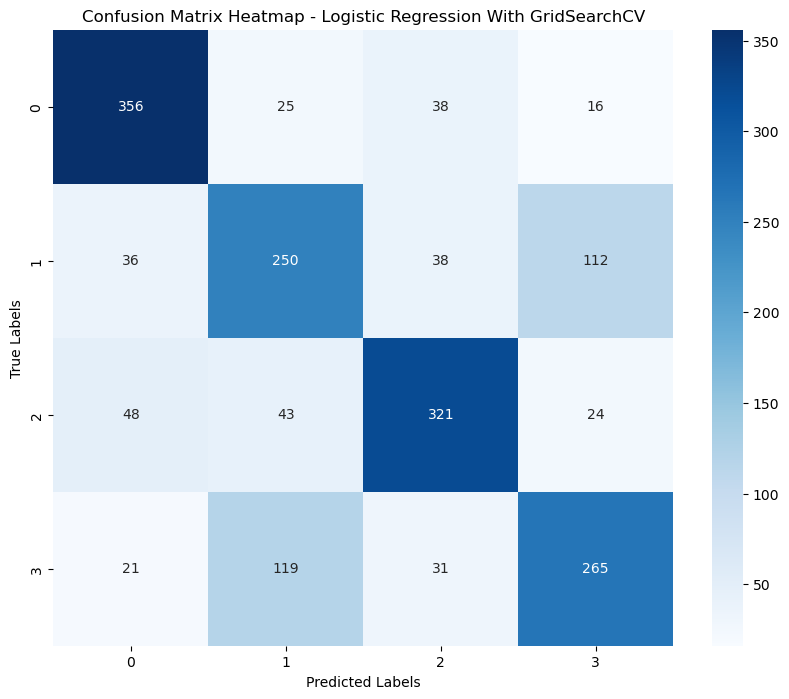

In [21]:
# Compute confusion matrix between true and predicted labels
cm = confusion_matrix(test_y, y_pred)

# Set figure size for readability
plt.figure(figsize=(10, 8))  

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)       

# Labelling of axis and title
plt.xlabel('Predicted Labels')  
plt.ylabel('True Labels')       
plt.title('Confusion Matrix Heatmap - Logistic Regression With GridSearchCV')  

# Display the heatmap
plt.show() 

#### **Key Observations and Insights from Confusion Matrix:**

**1. Strong performance on extreme classes (0 and 2)**

The model performs relatively well in identifying both no depression (class 0) and moderate depression (class 2), as seen from the high diagonal values (356 and 321 respectively). This indicates that the embeddings combined with Logistic Regression are able to capture clearer linguistic or semantic patterns for these two categories. However, even for these stronger classes, there is still some leakage into adjacent classes, suggesting that boundaries between severity levels are not perfectly separable.

**2. Significant confusion between mild (1) and severe (3) depression**

A major pattern in the matrix is the confusion between class 1 (mild) and class 3 (severe). For instance, 112 mild cases are misclassified as severe, and 119 severe cases are misclassified as mild. This indicates that the model struggles to differentiate between the two extremes of symptom expression when textual signals are ambiguous or overlapping, suggesting that the language used in mild and severe cases may share similar emotional intensity markers.

**3. Class 1 (mild depression) is the weakest performing category**

Class 1 shows the lowest diagonal dominance relative to its misclassifications, with many instances being incorrectly predicted as class 3 (112 cases). This suggests that the model has difficulty capturing the subtle differences that define mild depression, often pushing predictions toward more extreme or neutral categories. This may reflect either label ambiguity in the dataset or insufficient discriminative features for early-stage symptoms.

**4. Overall tendency toward boundary confusion rather than random errors**

The misclassifications are not random but concentrated between adjacent severity levels. This indicates that the model is learning a partially ordinal structure in depression severity, where errors mostly occur between conceptually neighboring classes rather than completely unrelated ones. This is a positive sign, suggesting that a more ordinal-aware model (ordinal regression or weighted loss functions) could further improve performance.